In [72]:
import pandas as pd

# 1️⃣ 读取并预处理函数
def load_and_clean(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

    # 时间戳统一到微秒
    df['Close Time'] = df['Close Time'].apply(lambda x: x * 1000 + 999 if x < 2000000000000 else x)
    df['Open Time']  = df['Open Time'] .apply(lambda x: x * 1000       if x < 2000000000000 else x)

    df['Close Time'] = pd.to_datetime(df['Close Time'], unit='us')
    df['Open Time']  = pd.to_datetime(df['Open Time'],  unit='us')
    return df.set_index("Close Time")

# 2️⃣ 逐个读入
btc  = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/BTCUSDT_klines_5m.csv")
btc_tp  = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw_tp/BTCUSDT_klines_5m.csv")
doge = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/DOGEUSDT_klines_5m.csv")
xrp  = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/XRPUSDT_klines_5m.csv")
pepe = load_and_clean("/Users/lizeyu/Desktop/qoc/tmp/raw/5m_klines_raw/PEPEUSDT_klines_5m.csv")

# 3️⃣ 找共同 index（循环交集）
common_index = set(btc.index)
for df in [doge, xrp, pepe]:
    common_index = common_index & set(df.index)

common_index = sorted(common_index)  # 转回有序列表

btc = pd.concat([btc, btc_tp], axis=0)  # axis=0 表示按行拼
btc.sort_index(inplace=True)
doge.sort_index(inplace=True)
xrp.sort_index(inplace=True)
pepe.sort_index(inplace=True)

btc.drop_duplicates(inplace=True)
doge.drop_duplicates(inplace=True)
xrp.drop_duplicates(inplace=True)
pepe.drop_duplicates(inplace=True)



In [73]:
df = btc

In [74]:
btc

,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore
Close Time,,,,,,,,,,,,
2022-07-01 00:04:59.999999,0,2022-07-01 00:00:00,19942.21,19978.47,19671.54,19720.27,1500.73213,2.973862e+07,18444,692.71753,1.373040e+07,0
2022-07-01 00:09:59.999999,1,2022-07-01 00:05:00,19720.28,19824.99,19658.97,19779.77,945.32135,1.866176e+07,11457,487.43124,9.621930e+06,0
2022-07-01 00:14:59.999999,2,2022-07-01 00:10:00,19779.77,19812.58,19707.00,19724.38,617.76929,1.221068e+07,7521,244.41978,4.829768e+06,0
2022-07-01 00:19:59.999999,3,2022-07-01 00:15:00,19724.39,19811.69,19704.56,19795.44,464.63898,9.179269e+06,6709,225.60132,4.456851e+06,0
2022-07-01 00:24:59.999999,4,2022-07-01 00:20:00,19795.43,19813.30,19748.36,19750.16,323.53863,6.399147e+06,4252,167.23182,3.308143e+06,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-31 23:39:59.999999,105115,2025-08-31 23:35:00,108251.22,108416.35,108111.00,108156.01,113.69077,1.230942e+07,16780,65.43264,7.086852e+06,0
2025-08-31 23:44:59.999999,105116,2025-08-31 23:40:00,108156.00,108258.00,108076.93,108258.00,102.71622,1.110862e+07,13502,56.70324,6.131969e+06,0
2025-08-31 23:49:59.999999,105117,2025-08-31 23:45:00,108257.99,108356.05,108194.86,108283.23,86.46452,9.361689e+06,12602,53.26288,5.766744e+06,0


In [75]:
# 添加一列表示 index 所在的小时
df['Hour'] = df.index.hour
df['Day'] = df.index.date

# 添加一列表示 Close 相对于 144 行前的涨幅
df['Close_Change_12'] = (df['Close'].shift(-12)-df['Close']) / df['Close']
df['Close_Change_144'] = (df['Close'].shift(-144)-df['Close']) / df['Close']

df.head(20)

,index,Open Time,Open,High,Low,Close,Volume,Quote Asset Volume,Number of Trades,Taker Buy Base Volume,Taker Buy Quote Volume,Ignore,Hour,Day,Close_Change_12,Close_Change_144
Close Time,,,,,,,,,,,,,,,,
2022-07-01 00:04:59.999999,0,2022-07-01 00:00:00,19942.21,19978.47,19671.54,19720.27,1500.73213,2.973862e+07,18444,692.71753,1.373040e+07,0,0,2022-07-01,0.031931,-0.025768
2022-07-01 00:09:59.999999,1,2022-07-01 00:05:00,19720.28,19824.99,19658.97,19779.77,945.32135,1.866176e+07,11457,487.43124,9.621930e+06,0,0,2022-07-01,0.028177,-0.029471
2022-07-01 00:14:59.999999,2,2022-07-01 00:10:00,19779.77,19812.58,19707.00,19724.38,617.76929,1.221068e+07,7521,244.41978,4.829768e+06,0,0,2022-07-01,0.029146,-0.026068
2022-07-01 00:19:59.999999,3,2022-07-01 00:15:00,19724.39,19811.69,19704.56,19795.44,464.63898,9.179269e+06,6709,225.60132,4.456851e+06,0,0,2022-07-01,0.027409,-0.033147
2022-07-01 00:24:59.999999,4,2022-07-01 00:20:00,19795.43,19813.30,19748.36,19750.16,323.53863,6.399147e+06,4252,167.23182,3.308143e+06,0,0,2022-07-01,0.028365,-0.029507
2022-07-01 00:29:59.999999,5,2022-07-01 00:25:00,19750.15,20699.99,19750.11,20491.03,3427.47541,6.942624e+07,37118,2098.52562,4.248955e+07,0,0,2022-07-01,-0.004930,-0.061491
2022-07-01 00:34:59.999999,6,2022-07-01 00:30:00,20491.03,20918.35,20432.60,20584.17,3010.74943,6.221877e+07,38190,1615.14635,3.339030e+07,0,0,2022-07-01,-0.013594,-0.063671
2022-07-01 00:39:59.999999,7,2022-07-01 00:35:00,20584.16,20598.49,20367.92,20381.81,1566.20324,3.206373e+07,19249,759.48995,1.554742e+07,0,0,2022-07-01,0.000974,-0.054505
2022-07-01 00:44:59.999999,8,2022-07-01 00:40:00,20381.82,20497.04,20369.60,20412.41,1183.34036,2.417769e+07,13033,574.63379,1.174135e+07,0,0,2022-07-01,0.000587,-0.053568


Processing: 100%|██████████| 333488/333488 [00:01<00:00, 261307.31it/s]


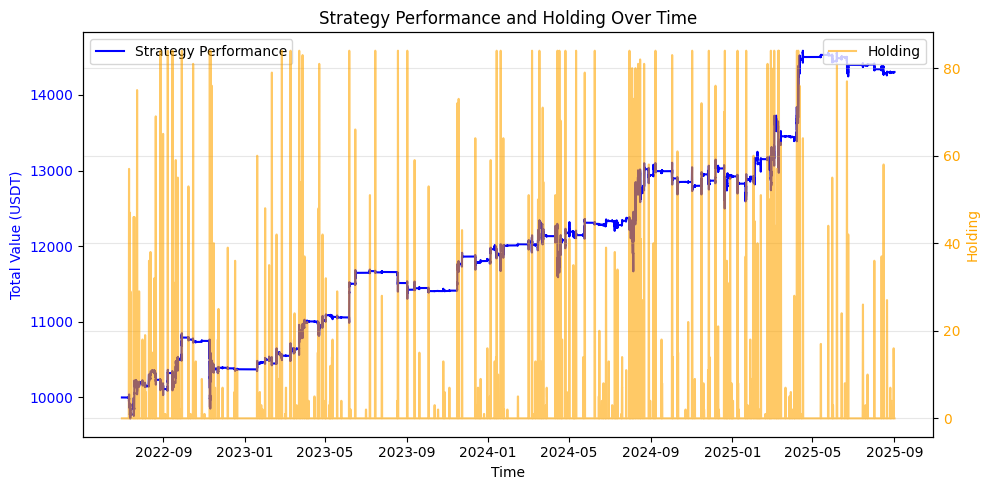

In [94]:
import numpy as np
import pandas as pd
from collections import deque
from tqdm import tqdm

def implement_strategy(
    btc: pd.DataFrame,
    trade_size: float=1000.0,
    initial_cap: float = 10000.0,
    fee: float = 0.0005,
    threshold: float = -0.02,
    max_holding: int = 24,

):

    prices = btc["Close"].values
    n = len(prices)

    # 预分配结果
    total_value = np.zeros(n)
    holdings_array = np.zeros(n)
    pnl_records = np.zeros(n)  # 每次平仓的收益率记录

    # 策略状态
    capital = initial_cap     # USDT
    amount = 0.0              # 持仓BTC数量
    open_orders = deque()     # 存储未平仓订单 [{time, price, qty}]
    now_holding = 0

    for t in tqdm(range(n), desc="Processing"):
        price_t = prices[t]
        total_value[t] = capital + amount * price_t
        holdings_array[t] = now_holding

        # --- 买入信号 ---
        if (
            t >= 288 
            and btc['Close_Change_144'].iloc[t-288]<threshold
            and now_holding<max_holding
            and btc['Hour'].iloc[t] in [7,8,9,10,11,12,13]  # 只能在0点、8点、16点买
        ):
            qty = trade_size / price_t
            cost = trade_size * (1 + fee)

            if capital >= cost:  # 资金充足才买
                capital -= cost
                amount += qty
                now_holding += 1
                open_orders.append({"time": t, "price": price_t, "qty": qty})
             
        if now_holding > 0:
            # 平多仓
            while open_orders and open_orders[0]["time"] <= t - 144:
                order = open_orders.popleft()
                sell_qty = order["qty"]
                sell_price = price_t
                proceeds = sell_qty * sell_price * (1 - fee)
                capital += proceeds
                amount -= sell_qty
                now_holding -= 1

                # 计算并记录收益率
                entry_price = order["price"]
                pnl = (sell_price - entry_price) / entry_price
                pnl_records[t] += pnl
       
    # 生成结果
    performance_df = pd.DataFrame(
        {"Total Value": total_value}, index=btc.index
    )
    holding_series = pd.Series(holdings_array, index=btc.index)
    pnl_series = pd.Series(pnl_records, index=btc.index)
    return performance_df, pnl_series, holding_series


# 运行优化后的策略
strategy_performance, pnls, holding = implement_strategy(
    btc,
    trade_size=100.0,
    initial_cap=10000.0,
    fee=0.0005,
    threshold=-0.02,
    max_holding=100,

)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
ax1 = plt.gca()
ax2 = ax1.twinx()





# 策略表现
ax1.plot(strategy_performance.index, strategy_performance['Total Value'], label='Strategy Performance', color='blue')
ax1.set_ylabel('Total Value (USDT)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 持仓
ax2.plot(strategy_performance.index, holding.values, label='Holding', color='orange', alpha=0.6)
ax2.set_ylabel('Holding', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Strategy Performance and Holding Over Time')
ax1.set_xlabel('Time')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [95]:
# 筛选出 pnls 不等于 0 的值
non_zero_pnls = pnls[pnls != 0]

# 打印前几行以验证
print(non_zero_pnls.head())
# 将 pnls 转换为 numpy 数组以便计算
import numpy as np
pnls_array = np.array(non_zero_pnls)

# 计算基本统计指标
stats = {
    "总交易次数": len(pnls_array),
    "平均收益率": np.mean(pnls_array),
    "中位数收益率": np.median(pnls_array),
    "最大收益率": np.max(pnls_array),
    "最小收益率": np.min(pnls_array),
    "标准差": np.std(pnls_array),
    "正收益交易数": np.sum(pnls_array > 0),
    "负收益交易数": np.sum(pnls_array < 0),
    "胜率": np.mean(pnls_array > 0),
    "盈亏比": np.mean(pnls_array[pnls_array > 0]) / abs(np.mean(pnls_array[pnls_array < 0])) if np.any(pnls_array < 0) else float('inf'),
    "夏普比率": np.mean(pnls_array) / np.std(pnls_array) if np.std(pnls_array) > 0 else 0,
    "总收益率": np.sum(pnls_array)
}

# 打印统计指标
for key, value in stats.items():
    print(f"{key}: {value:.4f}" if isinstance(value, (float, np.float64)) else f"{key}: {value}")

Close Time
2022-07-11 19:04:59.999999    0.005029
2022-07-11 19:09:59.999999    0.005023
2022-07-11 19:14:59.999999    0.003100
2022-07-11 19:19:59.999999   -0.000258
2022-07-11 19:24:59.999999    0.000393
dtype: float64
总交易次数: 9701
平均收益率: 0.0054
中位数收益率: 0.0033
最大收益率: 0.1252
最小收益率: -0.1187
标准差: 0.0267
正收益交易数: 5534
负收益交易数: 4167
胜率: 0.5705
盈亏比: 1.3395
夏普比率: 0.2036
总收益率: 52.7690
